# WELCOME to the Universe

This notebook runs the theory-driven WELCOME pipeline and visualises the generated realisations. No reference simulation data are required.


## 1. Installation

Install WELCOME with `pip install welcome-to-the-universe`.


In [ ]:
%pip install welcome-to-the-universe

## 2. Imports


In [ ]:
from pathlib import Path

from welcome import WelcomeConfig, load_welcome_result
from welcome.plotting import (
    plot_example_map,
    plot_source_redshift_distribution,
    plot_power_realisations,
    prepare_wavelet_diagnostics,
    plot_wavelet_l1,
    plot_wavelet_moments,
)

## 3. User settings

Set `single_plane=True` to use the exact `source_redshift`; set `single_plane=False` to use the source distribution stored in `nz_file` instead.


In [ ]:
# Output directory
OUTPUT_DIR = Path(r"E:\WELCOME_output")

# Core cosmological parameters
H = 0.70
OMEGA_B = 0.046
OMEGA_CDM = 0.233
SIGMA8 = 0.82
N_S = 0.97

# Source population
SINGLE_PLANE = True
SOURCE_REDSHIFT = 1.0334
NZ_FILE = None  # Example: Path("Euclid_like_nz.npy") when SINGLE_PLANE = False

# Map generation
NSIDE = 512
LMAX = 1535
N_REALISATIONS = 10
N_ITERATIONS = 30
N_JOBS = 5

### Advanced settings


In [ ]:
# These defaults normally do not need to be changed.
SUM_MNU_EV = 0.0
A_S_TIMES_1E9 = 2.10
W0 = -1.0
WA = 0.0
HALOFIT_VERSION = "mead2020"
THEORY_NSIDE = 4096
THEORY_ELL_MAX = 3000
N_POWER_SPECTRUM_BINS = 40
THEORY_RANDOM_SEED = 12345
MAP_RANDOM_SEED = 14
HARMONIC_ITER = 3
OVERWRITE = False

## 4. Run WELCOME


In [ ]:
config = WelcomeConfig(
    h=H,
    omega_b=OMEGA_B,
    omega_cdm=OMEGA_CDM,
    sigma8=SIGMA8,
    n_s=N_S,
    single_plane=SINGLE_PLANE,
    source_redshift=SOURCE_REDSHIFT,
    nz_file=NZ_FILE,
    nside=NSIDE,
    lmax=LMAX,
    n_realisations=N_REALISATIONS,
    n_iterations=N_ITERATIONS,
    n_jobs=N_JOBS,
    output_dir=OUTPUT_DIR,
    sum_mnu_ev=SUM_MNU_EV,
    a_s_times_1e9=A_S_TIMES_1E9,
    w0=W0,
    wa=WA,
    halofit_version=HALOFIT_VERSION,
    theory_nside=THEORY_NSIDE,
    theory_ell_max=THEORY_ELL_MAX,
    n_power_spectrum_bins=N_POWER_SPECTRUM_BINS,
    theory_random_seed=THEORY_RANDOM_SEED,
    random_seed=MAP_RANDOM_SEED,
    harmonic_iter=HARMONIC_ITER,
    overwrite=OVERWRITE,
)

result = load_welcome_result(config, run_if_missing=True)

[WELCOME] Existing result loaded from: E:\WELCOME_output


## 5. Example generated convergence map


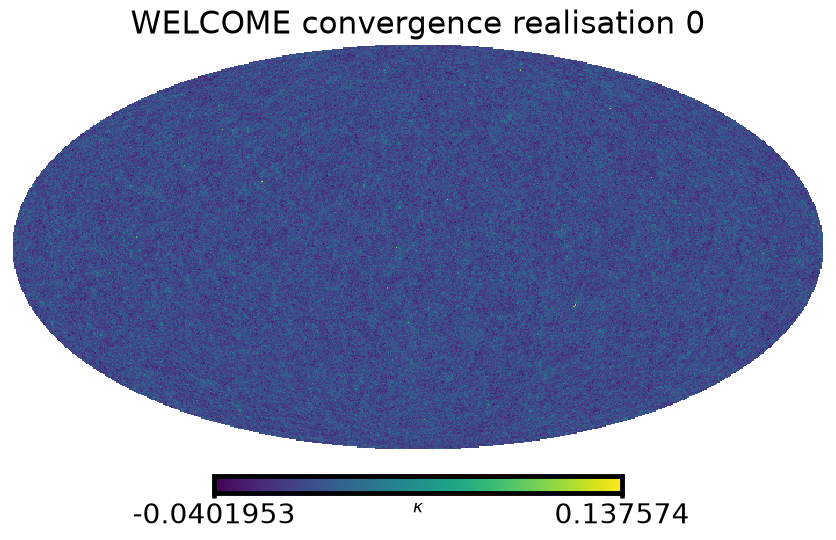

In [ ]:
plot_example_map(result, realisation=0);

## 6. Source redshift distribution


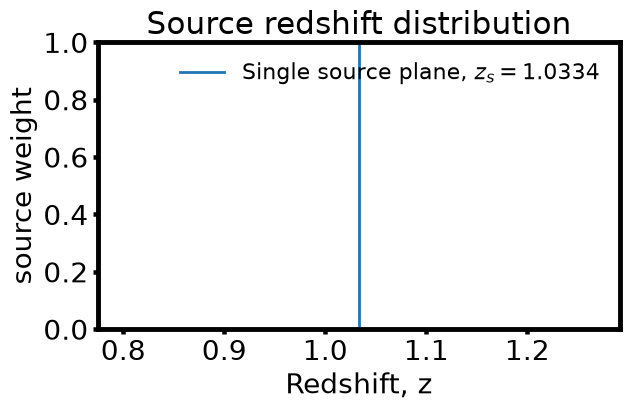

In [ ]:
plot_source_redshift_distribution(result);

## 7. Theoretical and emulated power-spectrum realisations

Each theoretical stochastic power-spectrum realisation is matched to the emulated map generated from that target. Thin curves show individual realisations and thick curves show the ensemble means.


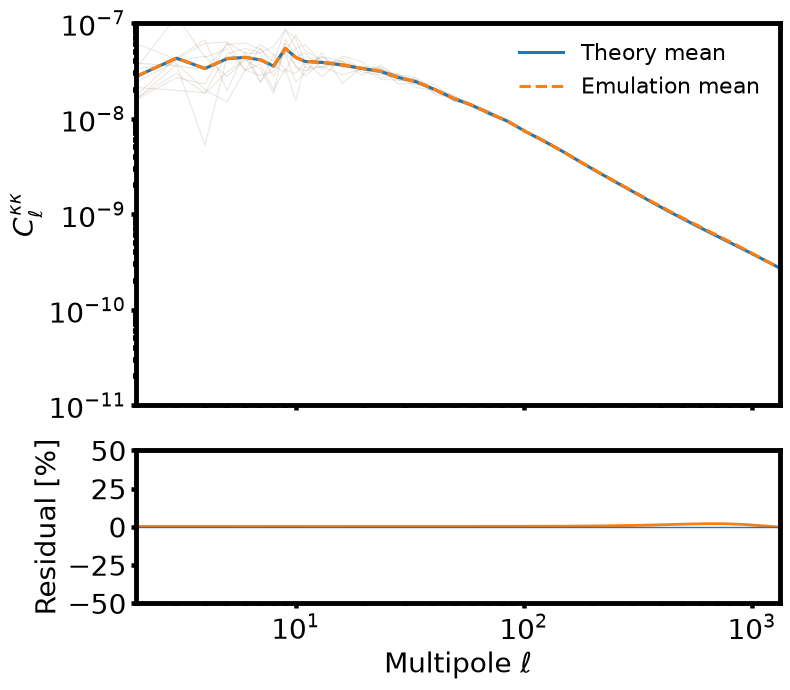

In [ ]:
plot_power_realisations(result);

## 8. Theory and emulation wavelet L1-norm

The diagnostic scales are 15-30, 18-36, 20-40, and 25-50 arcmin. The theoretical curve is deterministic at fixed cosmology and source population, whereas the emulation curves vary across map realisations.


[WAVELET] Loaded complete cached diagnostics: E:\WELCOME_output\emulated_map\nside512_lmax1535\wavelet_l1_prepared_15-30_18-36_20-40_25-50.npz


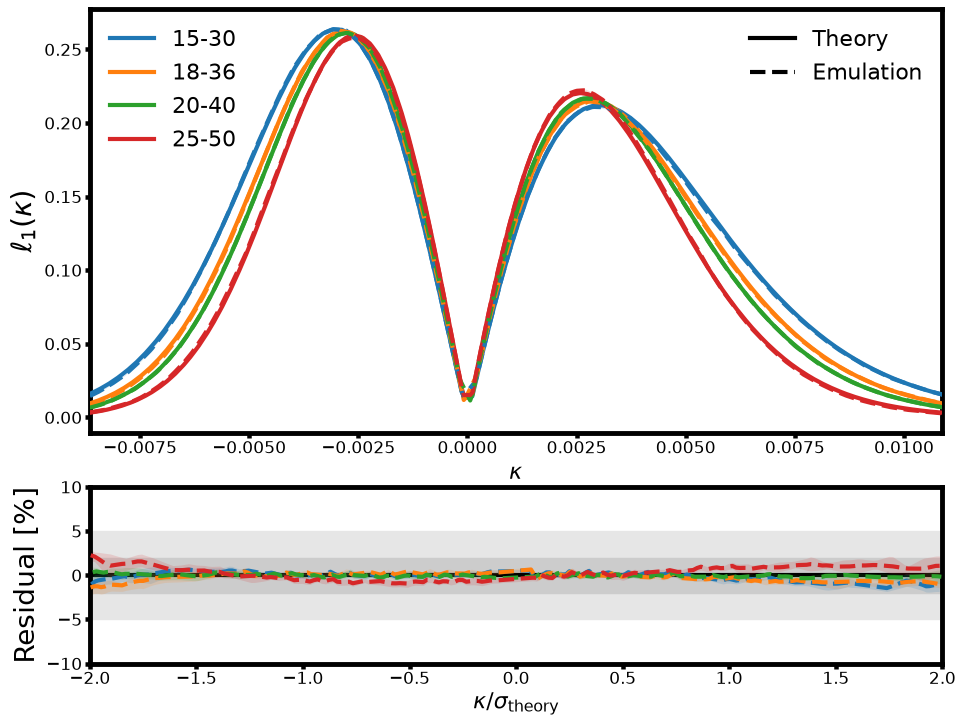

In [ ]:
diagnostics = prepare_wavelet_diagnostics(
    result,
    bands=((15.0, 30.0), (18.0, 36.0), (20.0, 40.0), (25.0, 50.0)),
)

plot_wavelet_l1(diagnostics);

## 9. L1-weighted moments

The theory provides one value per wavelet scale. The emulation markers show the ensemble mean and empirical central 95% interval across generated realisations.


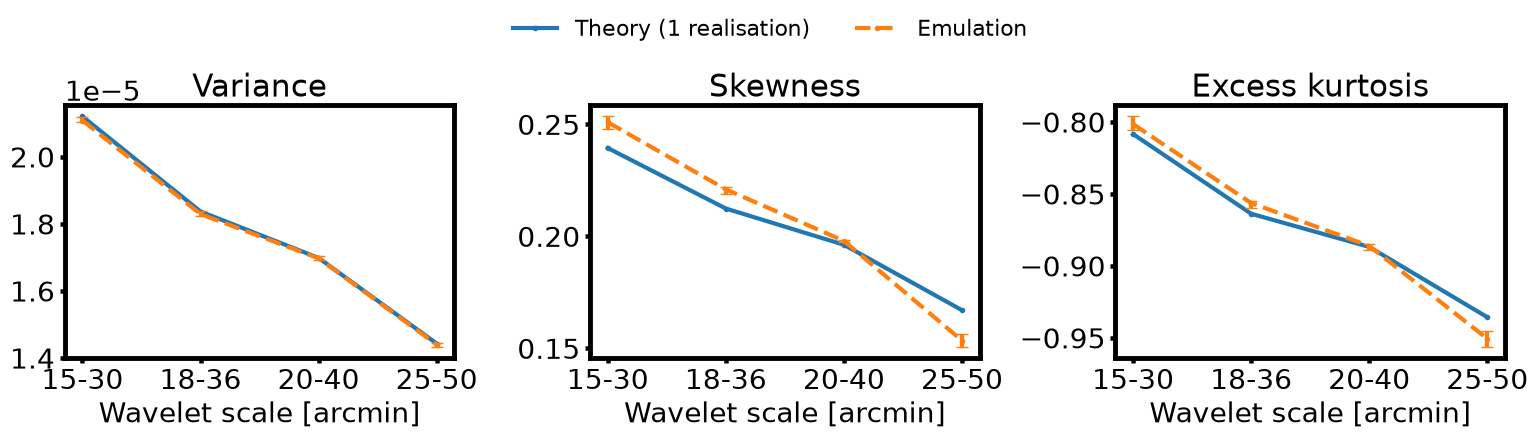

In [ ]:
plot_wavelet_moments(diagnostics);